In [ ]:
# CREATE SOME PLOTS FOR CITY OF TORONTO STUFF TO EXPLORE CLIMATE CHANGE IMPACTS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("C:/Users/semih/visualization/02_activities/assignment3_files/Climate Variables.csv")

# Check column names
print(df.columns)

Index(['_id', 'Climate Scenario', 'Time Horizon', 'Distribution',
       'ANNUAL_MEAN_TEMPERATURE', 'WINTER_MEAN_TEMPERATURE',
       'SPRING_MEAN_TEMPERATURE', 'SUMMER_MEAN_TEMPERATURE',
       'FALL_MEAN_TEMPERATURE', 'ANNUAL_MAXIMUM_TEMPERATURE',
       'WINTER_MAXIMUM_TEMPERATURE', 'SPRING_MAXIMUM_TEMPERATURE',
       'SUMMER_MAXIMUM_TEMPERATURE', 'FALL_MAXIMUM_TEMPERATURE',
       'ANNUAL_MINIMUM_TEMPERATURE', 'WINTER_MINIMUM_TEMPERATURE',
       'SPRING_MINIMUM_TEMPERATURE', 'SUMMER_MINIMUM_TEMPERATURE',
       'FALL_MINIMUM_TEMPERATURE', 'DAYS_ABOVE_35C', 'DAYS_ABOVE_30C',
       'DAYS_ABOVE_25C', 'DAYS_ABOVE_20C_TROPICAL_NIGHTS',
       'HOTTEST_DAY_TEMPERATURE', 'TEMPERATURE_BASED_HEAT_WARNING_FREQUENCY',
       'MAXIMUM_CONSECUTIVE_TEMPERATURE_BASED_HEAT_WARNING_DAYS',
       'HUMIDEX_ABOVE_30', 'HUMIDEX_ABOVE_35', 'HUMIDEX_ABOVE_40',
       'DAYS_BELOW_MINUS_20C', 'DAYS_BELOW_MINUS_10C',
       'DAYS_BELOW_0C_FROST_DAYS', 'HEATING_DEGREE_DAYS',
       'COOLING_DEGREE_DAYS', 

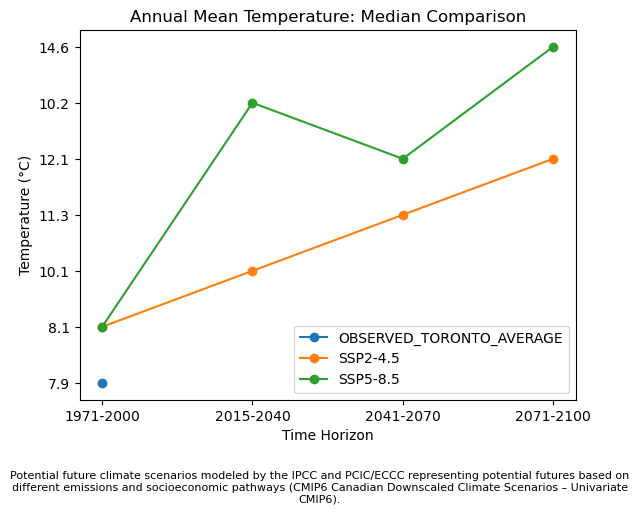

In [10]:
# BECAUSE CLIMATE MODELS PROVIDE A RANGE OF POSSIBLE FUTURES THE VALUES ARE PRESENTED IN PERCENTILES THE FOLLOWING
# CODE SHOWS ONLY MEDIAN VALUES WHICH INDICATES HALF OF THE MODELS ARE ABOVE THIS PREDICTION AND HALF OF THEM ARE BELOW 
# THIS PREDICTION

#SSP2-4.5 AND SSP5-8.5 REPRESENT DIFFERENT EMISSION SCNEARIOS MEDIUM EMISSION AND HIGH- EMISSION ACCORDINGLY. 

median = df[df["Distribution"] == "MEDIAN"]
for scenario in median["Climate Scenario"].unique():
    temp = median[median["Climate Scenario"] == scenario]
    plt.plot(temp["Time Horizon"], temp["ANNUAL_MEAN_TEMPERATURE"], marker="o", label=scenario)

desc = (
    "Potential future climate scenarios modeled by the IPCC and PCIC/ECCC "
    "representing potential futures based on different emissions and socioeconomic "
    "pathways (CMIP6 Canadian Downscaled Climate Scenarios – Univariate CMIP6)."
)


plt.title("Annual Mean Temperature: Median Comparison")
plt.xlabel("Time Horizon")
plt.ylabel("Temperature (°C)")
plt.figtext(0.5, -0.1, desc, wrap=True, ha="center", fontsize=8)
plt.legend()
plt.show()

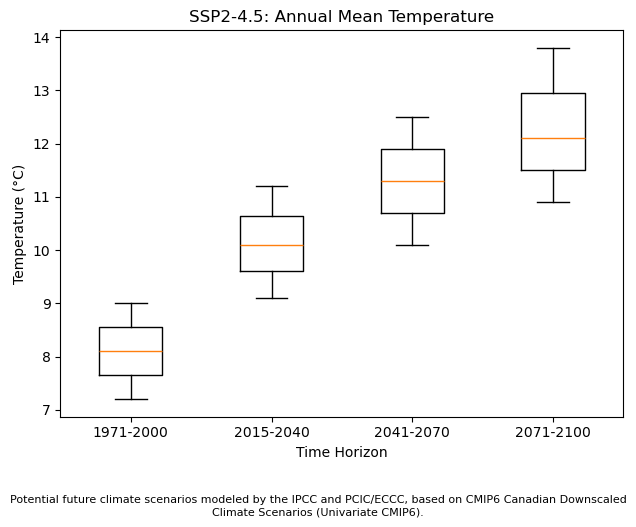

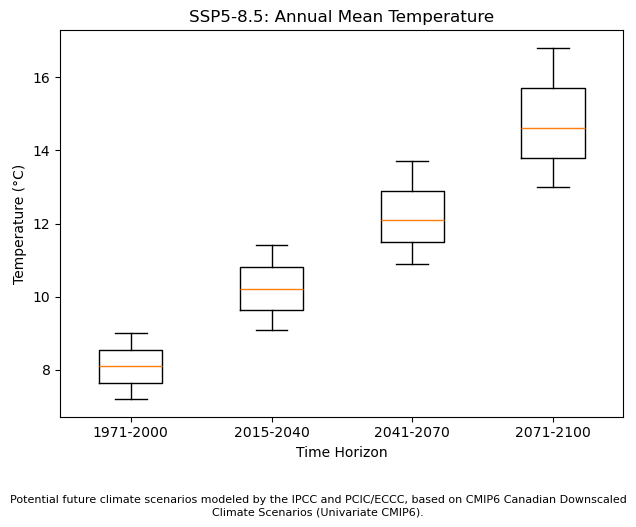

In [ ]:
#BUT MODELS COME WITH UNCERTAINTY! NOONE KNOWS WHICH MODEL IS MORE ACCURATE. 
# SO AS A DECISION MAKER IT IS IMPORTANT TO KNOW THE MODEL SPREAD SO PRESENTING FUTURE PREDICTIONS WITH 10TH  AND
# 90TH PERCENTILES IS A CRUCIAL STEP TO SEE HOW MODEL AGREEMENT VARIES FOR TIME HORIZONS AND EMISSION SCENARIOS.  

#  Keep only 10th, median, 90th rows
df = df[df["Distribution"].isin(["10th_PERCENTILE", "MEDIAN", "90th_PERCENTILE"])]

# Ensure the temperature column is numeric
df["ANNUAL_MEAN_TEMPERATURE"] = pd.to_numeric(df["ANNUAL_MEAN_TEMPERATURE"], errors="coerce")

# Optional: normalize spacing in time horizon labels
df["Time Horizon"] = df["Time Horizon"].astype(str).str.strip()

# Caption / alt text
desc = ("Potential future climate scenarios modeled by the IPCC and PCIC/ECCC, "
        "based on CMIP6 Canadian Downscaled Climate Scenarios (Univariate CMIP6).")

periods = ["1971-2000", "2015-2040", "2041-2070", "2071-2100"]

for scenario in ["SSP2-4.5", "SSP5-8.5"]:
    sub = df[df["Climate Scenario"] == scenario]
    data, labels = [], []

    for p in periods:
        vals = (
            sub.loc[sub["Time Horizon"] == p, "ANNUAL_MEAN_TEMPERATURE"]
            .dropna()
            .astype(float)
            .values
        )
        if len(vals) > 0:
            data.append(vals)
            labels.append(p)

    # Use tick_labels for newer Matplotlib versions
    plt.boxplot(data, tick_labels=labels)
    plt.title(f"{scenario}: Annual Mean Temperature")
    plt.xlabel("Time Horizon")
    plt.ylabel("Temperature (°C)")
    plt.figtext(0.5, -0.08, desc, ha="center", wrap=True, fontsize=8)
    plt.tight_layout()
    plt.show()

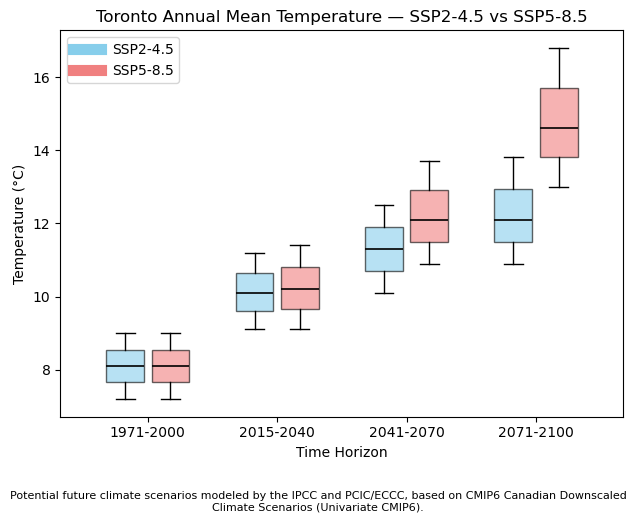

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean

df = df[df["Distribution"].isin(["10th_PERCENTILE", "MEDIAN", "90th_PERCENTILE"])]
df["ANNUAL_MEAN_TEMPERATURE"] = pd.to_numeric(df["ANNUAL_MEAN_TEMPERATURE"], errors="coerce")

# Description text (alt text)
desc = ("Potential future climate scenarios modeled by the IPCC and PCIC/ECCC, "
        "based on CMIP6 Canadian Downscaled Climate Scenarios (Univariate CMIP6).")

periods = ["1971-2000", "2015-2040", "2041-2070", "2071-2100"]
scenarios = ["SSP2-4.5", "SSP5-8.5"]

fig, ax = plt.subplots()

# Horizontal positions for grouped boxes
x = np.arange(len(periods))
width = 0.35  # half-distance between groups

colors = {"SSP2-4.5": "skyblue", "SSP5-8.5": "lightcoral"}

for i, scenario in enumerate(scenarios):
    sub = df[df["Climate Scenario"] == scenario]
    data = []
    for p in periods:
        vals = (
            sub.loc[sub["Time Horizon"] == p, "ANNUAL_MEAN_TEMPERATURE"]
            .dropna()
            .astype(float)
            .values
        )
        data.append(vals)
    
    # Shift positions for each scenario
    positions = x + (i - 0.5) * width
    bp = ax.boxplot(data, positions=positions, widths=width/1.2, patch_artist=True)
    
    for patch in bp['boxes']:
        patch.set(facecolor=colors[scenario], alpha=0.6)
    
    for median in bp['medians']:
        median.set(color='black', linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.set_xlabel("Time Horizon")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Toronto Annual Mean Temperature — SSP2-4.5 vs SSP5-8.5")
ax.legend([plt.Line2D([0], [0], color=colors[s], lw=8) for s in scenarios], scenarios)
plt.figtext(0.5, -0.07, desc, ha="center", wrap=True, fontsize=8)
plt.tight_layout()
plt.show()
